# Exploratory Data Analysis

In [1]:
# Imports
import os
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

sns.set(style="whitegrid")

Load the three CSVs and merge them.

In [2]:
DATA_DIR = Path("../finalproject_data/batch_1")

csv_files = [
    DATA_DIR / "batch1_1.csv",
    DATA_DIR / "batch1_2.csv",
    DATA_DIR / "batch1_3.csv"
]

dfs = []
for csv in csv_files:
    df = pd.read_csv(csv)
    df["batch_csv"] = csv.name
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df))
df.head()

Total rows: 1414


,File Name,Json Data,OCRed Text,batch_csv
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv


Parse *Json Data* column to usable columns.

In [3]:
def parse_json_safe(x):
    try:
        return json.loads(x)
    except:
        return {}

df["parsed_json"] = df["Json Data"].apply(parse_json_safe)

df.head()

,File Name,Json Data,OCRed Text,batch_csv,parsed_json
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,"{'invoice': {'client_name': 'Clark-Foster', 'c..."
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Williams, Schneid..."
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Hester Inc', 'cli..."
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"{'invoice': {'client_name': 'Olson, Cisneros a..."
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,"{'invoice': {'client_name': 'Wilson-Wilson', '..."


Extract the structured fields from *parsed_json* column.

In [4]:
def extract_fields(js):
    invoice = js.get("invoice", {})
    subtotal = js.get("subtotal", {})

    return pd.Series({
        "client_name": invoice.get("client_name"),
        "seller_name": invoice.get("seller_name"),
        "invoice_number": invoice.get("invoice_number"),
        "invoice_date": invoice.get("invoice_date"),
        "due_date": invoice.get("due_date"),
        "tax": subtotal.get("tax"),
        "total_amount": subtotal.get("total")
    })

fields = df["parsed_json"].apply(extract_fields)

df = pd.concat([df, fields], axis=1)

df.head()

,File Name,Json Data,OCRed Text,batch_csv,parsed_json,client_name,seller_name,invoice_number,invoice_date,due_date,tax,total_amount
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,"{'invoice': {'client_name': 'Clark-Foster', 'c...",Clark-Foster,Nguyen-Roach,84652373,02/23/2021,,21.18,232.95
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Williams, Schneid...","Williams, Schneider and Gomez",Scott-Howard,37451664,06/11/2020,,13.99,153.92
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Hester Inc', 'cli...",Hester Inc,"Bailey, Murray and Lewis",40108666,02/07/2020,,45.29,498.21
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"{'invoice': {'client_name': 'Olson, Cisneros a...","Olson, Cisneros and Moore","Merritt, Williams and Young",73285932,07/25/2017,,61.59,677.47
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,"{'invoice': {'client_name': 'Wilson-Wilson', '...",Wilson-Wilson,Fernandez Ltd,15288019,09/07/2014,,0.16,1.71


There are 1414 total invoices but 1413 unique image files. This means there is one duplicate to remove.

In [5]:
print("Total invoices:", len(df))
print("Unique image files:", df["File Name"].nunique())

Total invoices: 1414
Unique image files: 1413


Find and print the duplicate row in the CSV.

In [6]:
# Find boolean mask of duplicates in the 'File Name' column
is_duplicate = df.duplicated(subset=['File Name'])

# Filter the dataframe to show the duplicate rows
duplicate_rows = df[df.duplicated(subset=['File Name'], keep=False)]

print(duplicate_rows)

           File Name                                          Json Data  \
574  batch1-0575.jpg  \n{\n  "invoice": {\n    "client_name": "Grego...   
575  batch1-0575.jpg  \n{\n  "invoice": {\n    "client_name": "Grego...   

                                            OCRed Text     batch_csv  \
574  Invoice no: 48223084 Date of issue: 12/05/2018...  batch1_2.csv   
575  Invoice no: 48223084 Date of issue: 12/05/2018...  batch1_2.csv   

                                           parsed_json  client_name  \
574  {'invoice': {'client_name': 'Gregory Inc', 'cl...  Gregory Inc   
575  {'invoice': {'client_name': 'Gregory Inc', 'cl...  Gregory Inc   

          seller_name invoice_number invoice_date due_date    tax total_amount  
574  Rodriguez-Conley       48223084   12/05/2018           30,47       335,17  
575  Rodriguez-Conley       48223084   12/05/2018           30,47       335,17  


Remove the duplicate.

In [7]:
df.drop_duplicates(subset=['File Name'], inplace=True)

## Invoice Image Examples

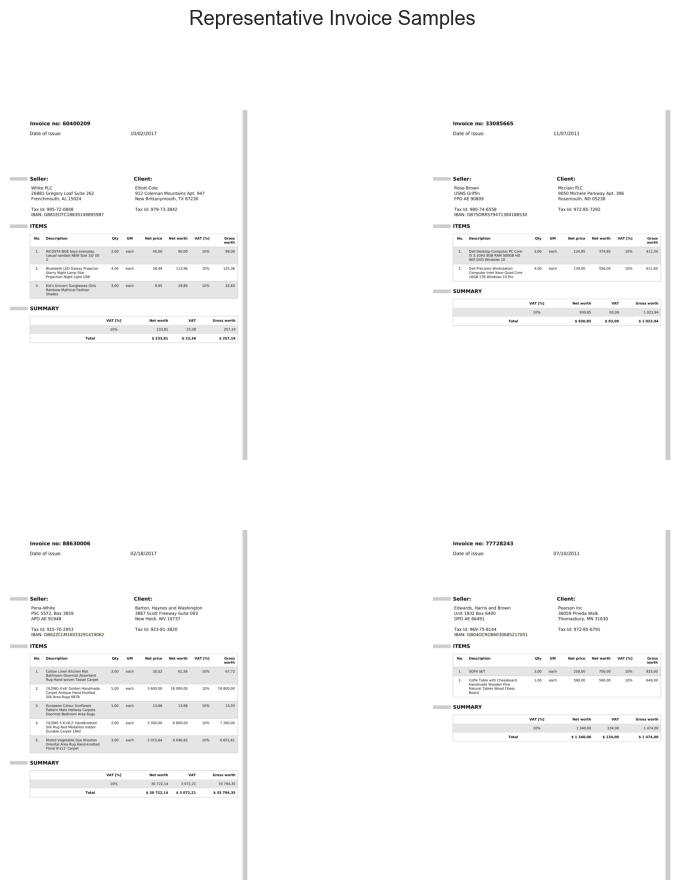

In [8]:
image_sample = df.sample(4)

fig, axes = plt.subplots(2,2, figsize=(10,10))

for ax, (_, row) in zip(axes.flatten(), image_sample.iterrows()):

    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR / folder / row["File Name"]

    img = Image.open(img_path)

    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Representative Invoice Samples")
plt.show()

# OCR Text Examples

In [9]:
ocr_text_sample = df.sample(5)

for _, row in ocr_text_sample.iterrows():

    print("Invoice number:", row["invoice_number"])
    print("OCR snippet:", row["OCRed Text"][:200])
    print()

Invoice number: 15686725
OCR snippet: Invoice no: 15686725 Date of issue: 03/11/2021 Seller: Client: Whitaker, Gray and Green Davidson, Smith and Gill 39588 Thomas Brook Suite 147 3577 Michael Fields Sullivanshire, NH 40856 Marquezstad, I

Invoice number: 91851148
OCR snippet: Invoice no: 91851148 Date of issue: 11/08/2015 Seller: Client: Freeman, Carter and Peterson Ryan-Harrison 653 Ferrell Corners 86000 Matthew Valleys Suite 493 West Matthewborough, NJ 47608 Fischermouth

Invoice number: 31311902
OCR snippet: Invoice no: 31311902 Date of issue: 06/04/2017 Seller: Client: Hodges, Porter and Bass Young, Rosales and Graham 80694 Black Corners 0004 Elizabeth Fall South Sean, VA 48650 Brianfort, HI 90540 Tax Id

Invoice number: 12590251
OCR snippet: Invoice no: 12590251 Date of issue: 01/17/2016 Seller: Client: Harrison, Tucker and Choi Logan-Rodriguez 012 Rachel Inlet Apt: 289 140 Gates Crossroad Apt: 980 Burgessmouth, OK 81442 Cannonchester, NV

Invoice number: 40631256
OCR snippet: In

## Missingness analysis

Explore which of the extracted fields have missing fields and how many.

In [ ]:
target_fields = [
    "client_name",
    "seller_name",
    "invoice_number",
    "invoice_date",
    "due_date",
    "tax",
    "total_amount"
]

# Function to handle data type and formatting
def enforce_invoice_dtypes(df):

    text_cols = [
        "client_name",
        "seller_name",
        "invoice_number"
    ]

    date_cols = [
        "invoice_date",
        "due_date"
    ]

    df = df.copy()

    # ---------- TEXT FIELDS ----------
    for col in text_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
        )

    # ---------- DATE FIELDS ----------
    for col in date_cols:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
        )

        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

    # ---------- CLEAN NUMERIC STRINGS ----------
    for col in ["tax", "total_amount"]:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.strip()
            .replace("", np.nan)
        )

    # ---------- HANDLE TAX PERCENTAGES ----------
    def compute_tax_value(tax_val, total_val):

        if pd.isna(tax_val):
            return np.nan

        # Percentage case
        if isinstance(tax_val, str) and tax_val.endswith("%"):

            try:
                rate = float(tax_val.replace("%","")) / 100

                total_val = float(total_val)

                subtotal = total_val / (1 + rate)

                tax_amount = total_val - subtotal

                return tax_amount

            except:
                return np.nan

        # Normal numeric case
        try:
            return float(tax_val)
        except:
            return np.nan

    # Convert total first
    df["total_amount"] = pd.to_numeric(
        df["total_amount"],
        errors="coerce"
    )

    # Compute tax
    df["tax"] = df.apply(
        lambda row: compute_tax_value(row["tax"], row["total_amount"]),
        axis=1
    )

    return df

df = enforce_invoice_dtypes(df)

missing_table = df[target_fields].isna().sum().sort_values(ascending=False)

print(missing_table)

due_date          1413
client_name          0
seller_name          0
invoice_number       0
invoice_date         0
tax                  0
total_amount         0
dtype: int64


Only one fields has missing values: *due_date*. Since *due_date* does not contain any values across all records, we will drop it.

In [13]:
df.drop(columns=["due_date"], inplace=True)

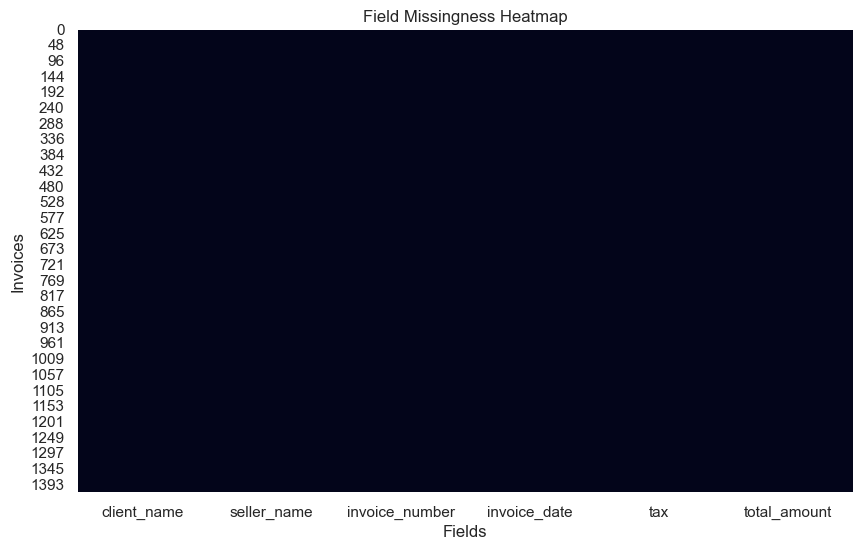

In [14]:
new_target_fields = [
    "client_name",
    "seller_name",
    "invoice_number",
    "invoice_date",
    "tax",
    "total_amount"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[new_target_fields].isna(), cbar=False)
plt.title("Field Missingness Heatmap")
plt.xlabel("Fields")
plt.ylabel("Invoices")
plt.show()

## Vendor distribution
Find how many vendors exist and how many invoices per vendor. 

There are 1361 unique vendors with the top occurring vendors only having 2 or 3 invoices. This may present a large variability in the types of products sold. 

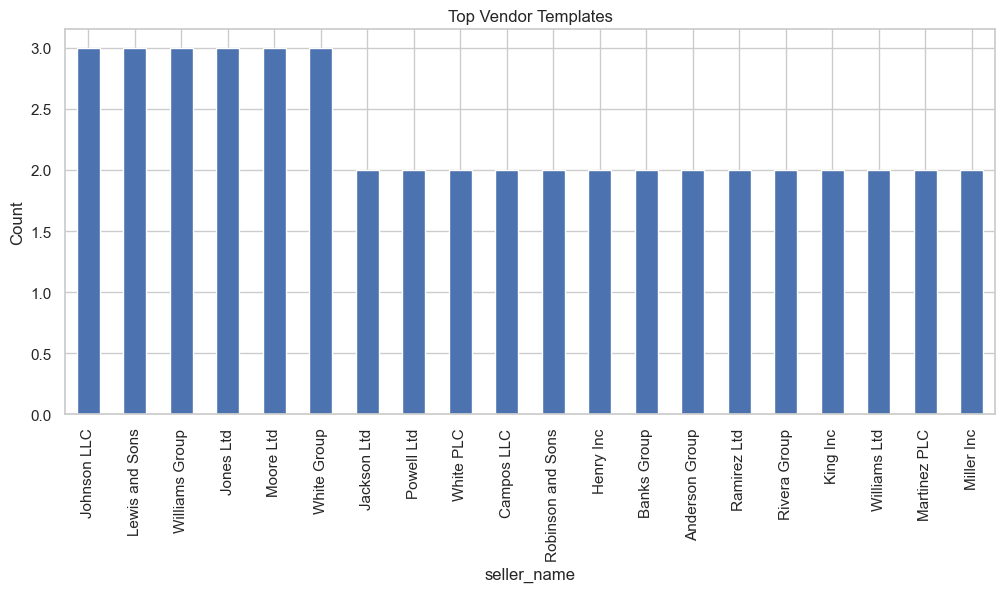

Unique vendors: 1361


In [15]:
vendor_counts = df["seller_name"].value_counts()

plt.figure(figsize=(12,5))
vendor_counts.head(20).plot(kind="bar")
plt.title("Top Vendor Templates")
plt.ylabel("Count")
plt.show()

print("Unique vendors:", df["seller_name"].nunique())

In [16]:
vendor_counts = df["seller_name"].value_counts()
print(vendor_counts)

seller_name
Johnson LLC                     3
Lewis and Sons                  3
Williams Group                  3
Jones Ltd                       3
Moore Ltd                       3
                               ..
Navarro Inc                     1
Mitchell, Acevedo and Wright    1
Thomas, Gonzalez and Bennett    1
Smith, Campbell and Gonzales    1
Burns, Figueroa and Hawkins     1
Name: count, Length: 1361, dtype: int64


## Currency detection
Find the currencies used in the invoices. It turns out they are all in US Dollars.

In [17]:
currency_symbols = ["$", "€", "£", "¥", "₹"]

def detect_currency(text):
    if pd.isna(text):
        return None
    for sym in currency_symbols:
        if sym in text:
            return sym
    return "unknown"

df["currency"] = df["OCRed Text"].apply(detect_currency)

df["currency"].value_counts()

currency
$    1413
Name: count, dtype: int64

## Image resolution & aspect ratio

It seems that the image sizes and aspect ratios are consistent across all image files in the data. 

In [18]:
image_sizes = []
aspect_ratios = []

for i, row in df.iterrows():

    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR / folder / row["File Name"]

    try:
        img = Image.open(img_path)
        w, h = img.size

        image_sizes.append((w,h))
        aspect_ratios.append(w/h)

    except:
        image_sizes.append((None,None))
        aspect_ratios.append(None)

df["width"] = [x[0] for x in image_sizes]
print(df["width"].value_counts())
df["height"] = [x[1] for x in image_sizes]
print(df["height"].value_counts())

df["aspect_ratio"] = aspect_ratios
print(df["aspect_ratio"].value_counts())

width
1654    1413
Name: count, dtype: int64
height
2339    1413
Name: count, dtype: int64
aspect_ratio
0.70714    1413
Name: count, dtype: int64


## OCR token counts
Measure document complexity. We see that the distribution of token count across all documents is relatively normal. However, there is a large number of invoices with 82-84 tokens per document.

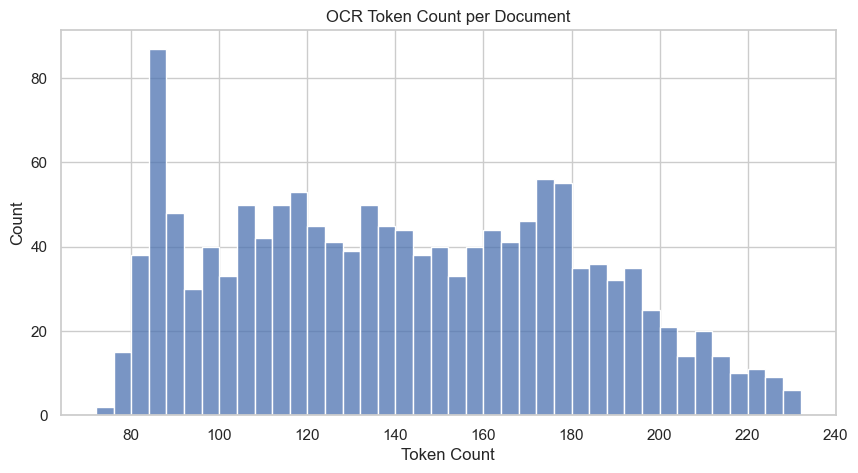

In [19]:
df["ocr_tokens"] = df["OCRed Text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(df["ocr_tokens"], bins=40)
plt.title("OCR Token Count per Document")
plt.xlabel("Token Count")
plt.show()

## Word Cloud
Common invoice vocabulary is shown in the word cloud below. The most common words are ones that represent the standard fields like Net worth, Tax, ID, VAT, etc.

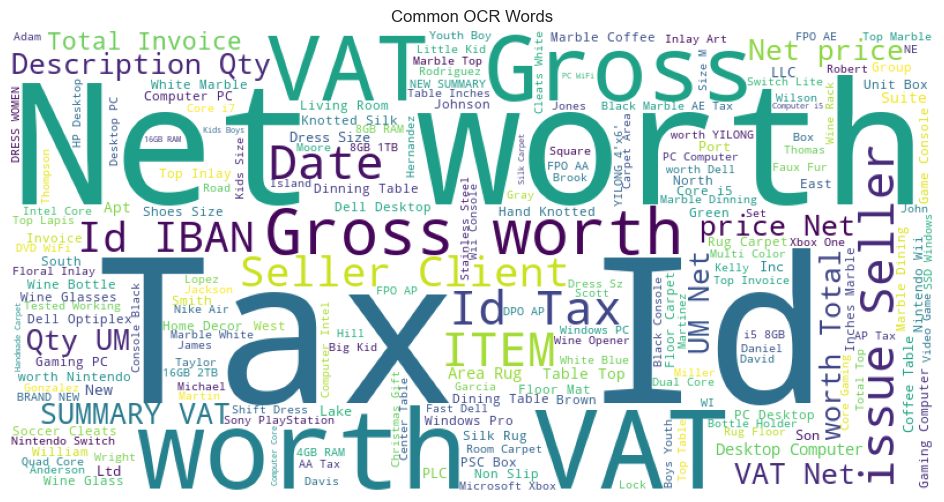

In [20]:
all_text = " ".join(df["OCRed Text"].astype(str))

wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Common OCR Words")
plt.show()

## Invoice number statistics

Check to see if the invoice number structure is standardized. We see that all of the invoice numbers are 8 characters long.

In [21]:
df["invoice_number_length"] = df["invoice_number"].astype(str).apply(len)
print(df["invoice_number_length"].value_counts())

invoice_number_length
8    1413
Name: count, dtype: int64


Check for noisy characters in invoice number. There is none.

In [22]:
df["invoice_number"].str.contains("[^0-9A-Za-z]", regex=True).mean()

np.float64(0.0)

## Total amount and tax analysis

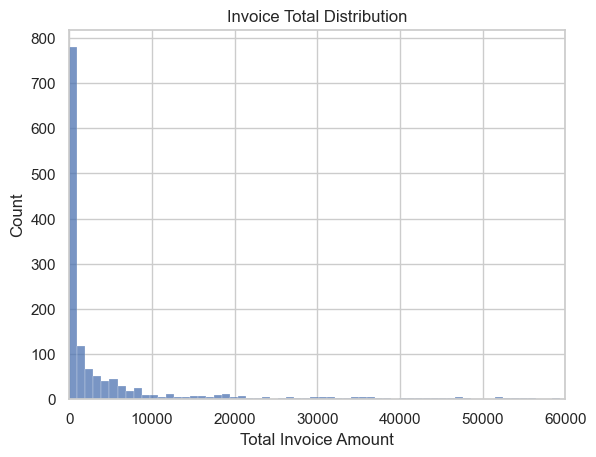

In [23]:
sns.histplot(df["total_amount"].dropna(), bins=200)
plt.xlim(0, 60000)
plt.title("Invoice Total Distribution")
plt.xlabel("Total Invoice Amount")
plt.show()

Identify the summary statistics for the invoice totals.

In [24]:
print("Summary Statistics of Total Amount:")
df["total_amount"].describe()

Summary Statistics of Total Amount:


count      1413.000000
mean       7844.664614
std       19257.110892
min           1.090000
25%         210.800000
50%         692.780000
75%        5013.800000
max      194521.700000
Name: total_amount, dtype: float64

In [25]:
print("Number of values:", len(df["total_amount"]))
print("Number of unique values: ", df['total_amount'].nunique())
print("Number of missing values: ", df['total_amount'].isna().sum())

Number of values: 1413
Number of unique values:  1374
Number of missing values:  0


Identify the summary statistics for the invoice tax.

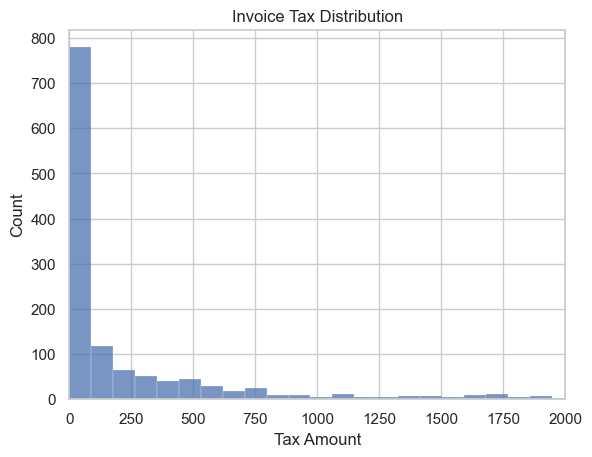

In [26]:
sns.histplot(df["tax"].dropna(), bins=200)
plt.xlim(0, 2000)
plt.title("Invoice Tax Distribution")
plt.xlabel("Tax Amount")
plt.show()

In [27]:
print("Summary Statistics of Invoice Tax:")
df["tax"].describe()

Summary Statistics of Invoice Tax:


count     1413.000000
mean       713.388594
std       1750.617141
min          0.100000
25%         19.160000
50%         62.980000
75%        455.800000
max      17683.790000
Name: tax, dtype: float64

In [28]:
print("Number of values:", len(df["tax"]))
print("Number of unique values: ", df['tax'].nunique())
print("Number of missing values: ", df['tax'].isna().sum())

Number of values: 1413
Number of unique values:  1300
Number of missing values:  0


## Initial baseline model

In [39]:
# Rule-based extraction pipeline + evaluation

import random
try:
    import pytesseract
    TESSERACT_AVAILABLE = True
except Exception:
    TESSERACT_AVAILABLE = False

# Configuration
DATA_DIR = Path("../finalproject_data/batch_1")  
CSV_FILES = [
    DATA_DIR / "batch1_1.csv",
    DATA_DIR / "batch1_2.csv",
    DATA_DIR / "batch1_3.csv"
]
# sample size
N_SAMPLE = 100
RANDOM_SEED = 42
USE_TESSERACT = True   # If USE_TESSERACT True but pytesseract not available, will fall back to CSV OCRed Text.

In [40]:
# Helper (same as above): enforce types
def enforce_invoice_dtypes(df):
    import numpy as np
    import pandas as pd

    text_cols = ["client_name", "seller_name", "invoice_number"]
    date_cols = ["invoice_date", "due_date"]

    df = df.copy()

    # TEXT FIELDS
    for col in text_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
            .replace("nan", np.nan)
        )

    # DATE FIELDS
    for col in date_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
            .replace("nan", np.nan)
        )
        df[col] = pd.to_datetime(df[col], errors="coerce")

    for col in ["tax", "total_amount"]:
        # ensure column exists
        if col not in df.columns:
            df[col] = np.nan
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.strip()
            .replace("", np.nan)
            .replace("nan", np.nan)
        )

    # compute tax numeric value when tax is percent string like "10%"
    def compute_tax_value(tax_val, total_val):
        if pd.isna(tax_val):
            return np.nan

        # Percentage case (ends with %)
        if isinstance(tax_val, str) and tax_val.strip().endswith("%"):
            try:
                rate = float(tax_val.strip().replace("%", "")) / 100.0
                total_num = float(total_val)
                subtotal = total_num / (1.0 + rate)
                tax_amount = total_num - subtotal
                return round(tax_amount, 2)
            except Exception:
                return np.nan

        # Numeric case (already normalized string)
        try:
            return float(tax_val)
        except Exception:
            return np.nan

    # Convert total_amount to numeric (coerce)
    df["total_amount"] = pd.to_numeric(df["total_amount"], errors="coerce")

    # compute tax numeric
    if "tax" in df.columns:
        df["tax"] = df.apply(lambda r: compute_tax_value(r["tax"], r["total_amount"]), axis=1)
    else:
        df["tax"] = np.nan

    return df

# Load CSVs, parse JSON, extract fields
def load_and_flatten(csv_paths):
    dfs = []
    for p in csv_paths:
        if not p.exists():
            print("Missing CSV:", p)
            continue
        tmp = pd.read_csv(p)
        tmp["batch_csv"] = p.name
        # Parse JSON safely
        def parse_js(x):
            try:
                return json.loads(x)
            except Exception:
                return {}
        tmp["parsed_json"] = tmp["Json Data"].apply(parse_js)
        dfs.append(tmp)
    if not dfs:
        raise FileNotFoundError("No CSVs loaded. Check DATA_DIR and CSV_FILES")
    df = pd.concat(dfs, ignore_index=True)
    # Extract canonical fields from parsed_json
    def extract_fields(js):
        invoice = js.get("invoice", {}) if isinstance(js, dict) else {}
        subtotal = js.get("subtotal", {}) if isinstance(js, dict) else {}
        return {
            "client_name": invoice.get("client_name"),
            "seller_name": invoice.get("seller_name"),
            "invoice_number": invoice.get("invoice_number"),
            "invoice_date": invoice.get("invoice_date"),
            "due_date": invoice.get("due_date"),
            "tax": subtotal.get("tax"),
            "total_amount": subtotal.get("total")
        }
    extracts = df["parsed_json"].apply(lambda js: pd.Series(extract_fields(js)))
    df = pd.concat([df, extracts], axis=1)
    return df

df_all = load_and_flatten(CSV_FILES)
print("Loaded rows:", len(df_all))

# enforce dtypes (with tax % handling)
df_all = enforce_invoice_dtypes(df_all)

Loaded rows: 1414


In [41]:
# select sample rows (only those with image files present)
def check_image_exists(row):
    # folder of images is based on batch_csv (e.g., batch1_1.csv -> batch1_1)
    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR / folder / row["File Name"]
    return img_path.exists()

df_all["image_exists"] = df_all.apply(check_image_exists, axis=1)
available = df_all[df_all["image_exists"] == True].copy()
print("Rows with images:", len(available))

random.seed(RANDOM_SEED)
if len(available) <= N_SAMPLE:
    sample_df = available.sample(len(available), random_state=RANDOM_SEED)
else:
    sample_df = available.sample(N_SAMPLE, random_state=RANDOM_SEED)

sample_df = sample_df.reset_index(drop=True)
print("Sampled rows:", len(sample_df))


# OCR helper: use CSV OCRed Text by default; optional pytesseract run
def get_ocr_text_for_row(row, use_tesseract=USE_TESSERACT):
    # prefer to run tesseract only if requested and available
    if use_tesseract and TESSERACT_AVAILABLE:
        folder = row["batch_csv"].replace(".csv","")
        img_path = DATA_DIR / folder / row["File Name"]
        try:
            img = Image.open(img_path)
            txt = pytesseract.image_to_string(img)
            if txt and txt.strip():
                return txt
        except Exception as e:
            # fall back
            pass
    # fallback: use OCRed Text column
    return str(row.get("OCRed Text", "") or "")

# gather OCRed text for sample
sample_df["ocr_text_used"] = sample_df.apply(lambda r: get_ocr_text_for_row(r, use_tesseract=USE_TESSERACT), axis=1)

Rows with images: 1414
Sampled rows: 100


In [45]:
# RULE-BASED extraction functions
_amount_re = re.compile(r"(?<!\w)(?:\$|€|£)?\s*([0-9]{1,3}(?:[.,][0-9]{3})*(?:[.,][0-9]{2}))")
_date_re = re.compile(r"\b(\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4})\b")
_iso_date_re = re.compile(r"\b(\d{4}-\d{2}-\d{2})\b")
_invoice_num_patterns = [
    re.compile(r"Invoice(?:\sNo\.?| No| Number|#)?[:\s\-]*([A-Z0-9\-]+)", flags=re.IGNORECASE),
    re.compile(r"Invoice\s*no[:\s]*([A-Z0-9\-]+)", flags=re.IGNORECASE),
    re.compile(r"\bINV[-]?\d{3,}\b", flags=re.IGNORECASE),
    re.compile(r"\b([A-Z]{2,}\d{4,})\b")  # fallback pattern: uppercase letters+digits
]
_seller_patterns = [
    re.compile(r"(Seller|Vendor|From)[:\s]*(.+)", flags=re.IGNORECASE),
    re.compile(r"Sold by[:\s]*(.+)", flags=re.IGNORECASE)
]
_client_patterns = [
    re.compile(r"(Client|Bill to|Bill To|Customer|Client:)[:\s]*(.+)", flags=re.IGNORECASE)
]
_total_keywords = [
    "total", "grand total", "summary", "gross worth", "gross", "amount due", "total $", "total:"
]

def find_invoice_number(text):
    for p in _invoice_num_patterns:
        m = p.search(text)
        if m:
            return m.group(1).strip()
    # fallback: search for long digit sequences
    m = re.search(r"\b\d{6,}\b", text)
    if m:
        return m.group(0)
    return None

def find_dates(text):
    # returns first matching date-like string
    m = _iso_date_re.search(text)
    if m:
        return m.group(1)
    m = _date_re.search(text)
    if m:
        return m.group(1)
    return None

def find_amounts(text):
    # returns list of numeric strings normalized (with '.' decimal)
    res = []
    for m in _amount_re.finditer(text):
        s = m.group(1)
        s = s.replace(".", "").replace(",", ".") if s.count(",") > 0 and s.count(".") == 0 else s.replace(",", "")
        # Normalize: ensure decimal dot exists
        if ',' in m.group(1) and '.' not in m.group(1):
            s = m.group(1).replace(",", ".")
        res.append(s)
    # fallback: also capture patterns like 139,93 or 153.92 etc handled above
    return res


def find_seller(text):
    # try patterns
    for p in _seller_patterns:
        m = p.search(text)
        if m:
            # group2 may include trailing lines; stop at newline or punctuation
            candidate = m.group(2).split("\n")[0].strip()
            # remove trailing 'Client:' if bad extraction
            candidate = re.split(r"(?i)Client:|Invoice", candidate)[0].strip()
            return candidate
    # fallback heuristic: sometimes 'Seller:' appears near 'Client:'; if not found, return None
    return None

def find_client(text):
    for p in _client_patterns:
        m = p.search(text)
        if m:
            candidate = m.group(2).split("\n")[0].strip()
            candidate = re.split(r"(?i)Seller:|Invoice", candidate)[0].strip()
            return candidate
    # fallback: try to infer client as the occurrence after 'Client:' or 'Bill to'
    return None

# Searches lines and nearby lines under a header
def find_amount_under_header(text, header_keywords):
    """
    Search for header keywords in the OCR text lines.
    If found, look on the same line, then next line, then previous line for an amount.
    Returns normalized amount string (e.g., '153.92') or None.
    """
    if not isinstance(text, str) or text.strip() == "":
        return None

    lines = [ln.strip() for ln in text.splitlines() if ln.strip() != ""]
    # precompute amounts per line
    line_amounts = []
    for ln in lines:
        m = _amount_re.search(ln)
        if m:
            amt = m.group(1)
            # normalize thousand/comma variants
            amt_norm = amt.replace(".", "").replace(",", ".") if amt.count(",") > 0 and amt.count(".") == 0 else amt.replace(",", "")
            line_amounts.append(amt_norm)
        else:
            line_amounts.append(None)

    lower_lines = [ln.lower() for ln in lines]
    for i, ln in enumerate(lower_lines):
        for kw in header_keywords:
            if kw.lower() in ln:
                # same line first
                if line_amounts[i]:
                    return line_amounts[i]
                # next line
                if i + 1 < len(line_amounts) and line_amounts[i+1]:
                    return line_amounts[i+1]
                # previous line
                if i - 1 >= 0 and line_amounts[i-1]:
                    return line_amounts[i-1]
                # as fallback, search a small window (i+2, i-2)
                if i + 2 < len(line_amounts) and line_amounts[i+2]:
                    return line_amounts[i+2]
                if i - 2 >= 0 and line_amounts[i-2]:
                    return line_amounts[i-2]
    return None

def find_total_near_keyword(text):
    # first try gross worth header specifically
    gross_amount = find_amount_under_header(text, ["gross worth", "gross"])
    if gross_amount:
        return gross_amount
    # else existing nearest-keyword logic (keeps original behavior)
    lower = text.lower()
    candidate_amounts = []
    amounts = []
    for m in _amount_re.finditer(text):
        amounts.append((m.start(), m.group(1)))
    for kw in _total_keywords:
        for m in re.finditer(re.escape(kw), lower):
            kw_pos = m.start()
            if not amounts:
                continue
            nearest = min(amounts, key=lambda a: abs(a[0] - kw_pos))
            candidate_amounts.append((abs(nearest[0] - kw_pos), nearest[1]))
    if candidate_amounts:
        candidate_amounts.sort(key=lambda x: x[0])
        amt = candidate_amounts[0][1]
        amt_norm = amt.replace(".", "").replace(",", ".") if amt.count(",") > 0 and amt.count(".") == 0 else amt.replace(",", "")
        return amt_norm
    amounts_list = find_amounts(text)
    if amounts_list:
        return amounts_list[-1]
    return None

# VAT-specific extractor using header context
def find_tax_by_vat_header(text):
    # look for "VAT", "VAT [%]" headers and numbers under them
    vat_amount = find_amount_under_header(text, ["vat", "vat [%]", "vat [%]"])
    if vat_amount:
        return vat_amount
    # fallback: search for explicit "VAT" with inline amount
    m_inline = re.search(r"(?:VAT|Tax)[^\d\n]*([\d]+[.,]\d{2})", text, flags=re.IGNORECASE)
    if m_inline:
        amt = m_inline.group(1)
        amt_norm = amt.replace(".", "").replace(",", ".") if amt.count(",") > 0 and amt.count(".") == 0 else amt.replace(",", "")
        return amt_norm
    # also accept percentage mentions (e.g., '10%')
    m_pct = re.search(r"(\d{1,2}(?:\.\d+)?\s*%)\s*(?:vat|tax)?", text, flags=re.IGNORECASE)
    if m_pct:
        return m_pct.group(1).strip()  # e.g., '10%'
    return None

# Update extract_with_rules to use the two new finders for tax and total
def extract_with_rules(text):
    t = text or ""
    t_clean = re.sub(r"\r\n", "\n", t)
    pred = {}
    pred["invoice_number"] = find_invoice_number(t_clean)
    pred["invoice_date"] = find_dates(t_clean)
    # use header-aware extractor for total/gross worth
    pred["total_amount"] = find_total_near_keyword(t_clean)
    # seller / client remain as before
    pred["seller_name"] = find_seller(t_clean)
    pred["client_name"] = find_client(t_clean)
    # tax: use VAT header extractor
    pred["tax"] = find_tax_by_vat_header(t_clean)
    return pred


# Normalization helpers
def normalize_text_field(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return None
    s = str(s).strip()
    if not s:
        return None
    # collapse whitespace and lowercase
    s = re.sub(r"\s+", " ", s)
    s = s.lower()
    # remove punctuation except internal & for alphanumeric invoice numbers keep dashes
    s = re.sub(r"[^\w\s\-]", "", s)
    s = s.strip()
    return s

def normalize_date_field(dt):
    # dt may be pandas.Timestamp or string like '06/11/2020' or None
    if pd.isna(dt) or dt is None:
        return None
    # try pandas to_datetime
    try:
        ts = pd.to_datetime(dt, errors="coerce")
        if pd.isna(ts):
            return None
        return ts.strftime("%Y-%m-%d")
    except Exception:
        return None

def normalize_amount_field(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    try:
        # remove currency signs and spaces, convert comma to dot if necessary
        s = str(x).strip()
        s = s.replace("$", "").replace("£", "").replace("€", "")
        # handle percentage strings (leave as-is)
        if s.endswith("%"):
            return s
        s = s.replace(" ", "")
        # replace thousand separators: handle both '1.234,56' and '1,234.56' heuristics
        # if there are both '.' and ',' choose the one which makes sense
        if s.count(",") > 0 and s.count(".") == 0:
            s = s.replace(",", ".")
        elif s.count(".") > 1 and s.count(",") == 0:
            # e.g., '1.234.56' -> delete dots except last? fallback simple: remove dots
            s = s.replace(".", "")
        else:
            s = s.replace(",", "")
        val = float(s)
        return round(val, 2)
    except Exception:
        return None

In [46]:
# Extraction and evaluation over sampled rows
preds = []
gt_records = []

for idx, row in sample_df.iterrows():
    ocr_text = row["ocr_text_used"]
    pred = extract_with_rules(ocr_text)
    # Normalize predictions
    pred_norm = {
    "invoice_number": normalize_text_field(pred.get("invoice_number")),
    "invoice_date": normalize_date_field(pred.get("invoice_date")),
    "total_amount": normalize_amount_field(pred.get("total_amount")),
    "seller_name": normalize_text_field(pred.get("seller_name")),
    "client_name": normalize_text_field(pred.get("client_name")),
    "tax": pred.get("tax")  # leave as-is for now (could be '13.99' or '10%')
    }

    tax_val_raw = pred_norm.get("tax")
    pred_total_val = pred_norm.get("total_amount")  # numeric or None

    def resolve_tax_pred(tax_raw, total_val):
    # tax_raw may be like '10%' or '13.99' (string) or numeric
        if tax_raw is None:
            return None
        # already normalized numeric (string without symbols) => use normalize_amount_field
        if isinstance(tax_raw, (int, float)):
            return round(float(tax_raw), 2)
        tax_s = str(tax_raw).strip()
        if tax_s.endswith("%"):
            # need total amount to compute tax dollars
            try:
                rate = float(tax_s.replace("%", "").strip()) / 100.0
                # if predicted total is missing, can't compute; try to use ground-truth total as fallback later
                if total_val is None:
                    return None
                total_f = float(total_val)
                subtotal = total_f / (1.0 + rate)
                tax_amount = total_f - subtotal
                return round(tax_amount, 2)
            except Exception:
                return None
        # otherwise try to parse numeric via normalize_amount_field
        parsed = normalize_amount_field(tax_s)
        return parsed
    pred_norm['tax'] = resolve_tax_pred(tax_val_raw, pred_total_val)

    preds.append(pred_norm)

    # Ground truth normalized
    gt = {
        "invoice_number": normalize_text_field(row.get("invoice_number")),
        "invoice_date": normalize_date_field(row.get("invoice_date")),
        "total_amount": normalize_amount_field(row.get("total_amount")),
        "seller_name": normalize_text_field(row.get("seller_name")),
        "client_name": normalize_text_field(row.get("client_name")),
        "tax": row.get("tax")  # tax already converted to numeric by enforce_invoice_dtypes
    }
    # normalize numeric gt tax
    gt["tax"] = round(float(gt["tax"]),2) if (gt["tax"] is not None and not (isinstance(gt["tax"], float) and np.isnan(gt["tax"]))) else None

    gt_records.append(gt)

# Convert to DataFrame for evaluation
pred_df = pd.DataFrame(preds)
gt_df = pd.DataFrame(gt_records)

eval_df = pd.concat([sample_df[["File Name", "batch_csv"]].reset_index(drop=True), gt_df, pred_df], axis=1)


# Exact-match accuracy per field (after normalization)
numeric_fields = ["total_amount", "tax"]
string_fields = ["invoice_number", "invoice_date", "seller_name", "client_name"]
fields_to_eval = string_fields + numeric_fields
    
accuracy_results = {}
# string fields: exact normalized match (ignore rows where GT missing)
for f in string_fields:
    gt_vals = gt_df[f]
    pred_vals = pred_df[f]
    mask = gt_vals.notna()
    total = mask.sum()
    if total == 0:
        acc = None
    else:
        acc = (gt_vals[mask] == pred_vals[mask]).sum() / total
    accuracy_results[f] = {"accuracy": acc, "count": int(total)}

# numeric fields: compare rounded values to 2 decimals
for f in numeric_fields:
    gt_vals = gt_df[f]
    pred_vals = pred_df[f]
    mask = gt_vals.notna()
    total = mask.sum()
    if total == 0:
        acc = None
    else:
        # only consider rows where both gt and pred numeric are present
        matched = 0
        considered = 0
        for g, p in zip(gt_vals[mask], pred_vals[mask]):
            if g is None or p is None:
                continue
            try:
                if round(float(g),2) == round(float(p),2):
                    matched += 1
                considered += 1
            except Exception:
                continue
        acc = (matched / considered) if considered > 0 else 0.0
    accuracy_results[f] = {"accuracy": acc, "count": int(total)}

# Numeric error metrics
def numeric_metrics(gt_series, pred_series):
    # assumes both are numeric floats or None
    arr = []
    for g, p in zip(gt_series, pred_series):
        if g is None or p is None:
            continue
        try:
            g_f = float(g)
            p_f = float(p)
            arr.append((g_f, p_f))
        except Exception:
            continue
    if not arr:
        return {"MAE": None, "MAPE": None, "N": 0}
    g_arr = np.array([x[0] for x in arr])
    p_arr = np.array([x[1] for x in arr])
    mae = np.mean(np.abs(g_arr - p_arr))
    # MAPE guard: avoid division by zero
    nonzero_mask = g_arr != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((g_arr[nonzero_mask] - p_arr[nonzero_mask]) / g_arr[nonzero_mask])) * 100.0
    else:
        mape = None
    return {"MAE": round(mae, 4) if mae is not None else None, "MAPE": round(mape,4) if mape is not None else None, "N": len(arr)}

num_metrics = {}
# total_amount
num_metrics["total_amount"] = numeric_metrics(gt_df["total_amount"], pred_df["total_amount"])
# tax
num_metrics["tax"] = numeric_metrics(gt_df["tax"], pred_df["tax"])


# OCR Alignment Sanity Metric
# For each field: % of rows where the GT serialized string appears in the OCR text (case-insensitive)
def appears_in_ocr(gt_val, ocr_text, field):
    if gt_val is None:
        return None
    if ocr_text is None or ocr_text == "":
        return False
    gt_str = str(gt_val).strip().lower()
    # simple contains check
    return gt_str in ocr_text.lower()

alignment = {}
for f in ["invoice_number", "invoice_date", "total_amount", "seller_name", "client_name", "tax"]:
    hits = 0
    total = 0
    for i, row in sample_df.reset_index(drop=True).iterrows():
        gt_val = gt_df.loc[i, f] if f in gt_df.columns else None
        if gt_val is None:
            continue
        total += 1
        ocr_txt = row["ocr_text_used"]
        if appears_in_ocr(gt_val, ocr_txt, f):
            hits += 1
    alignment[f] = {"matched_in_ocr": hits, "total_gt_exists": total, "percent": (hits/total*100.0 if total>0 else None)}

In [47]:
# Print summary report
print("\n=== FIELD-LEVEL EXACT MATCH ACCURACIES (normalized) ===")
for f, info in accuracy_results.items():
    if info["accuracy"] is None:
        print(f"{f}: no ground-truth examples to evaluate")
    else:
        print(f"{f}: {info['accuracy']*100:.2f}% (n={info['count']})")

print("\n=== NUMERIC ERROR METRICS ===")
for name, metrics in num_metrics.items():
    print(f"{name}: MAE={metrics['MAE']}, MAPE={metrics['MAPE']}%, N={metrics['N']}")

print("\n=== OCR ALIGNMENT SANITY METRIC ===")
for f, info in alignment.items():
    if info["total_gt_exists"] == 0:
        print(f"{f}: no ground-truth examples")
    else:
        print(f"{f}: {info['matched_in_ocr']}/{info['total_gt_exists']} ({info['percent']:.2f}%) of ground-truth values found verbatim in OCR text")


# Show some example mismatches for debugging
def show_mismatches(field, n=10):
    rows = []
    for i in range(len(sample_df)):
        gt = gt_df.loc[i, field] if field in gt_df.columns else None
        pred = pred_df.loc[i, field]
        if gt is None:
            continue
        if gt != pred:
            rows.append({
                "index": i,
                "file": sample_df.loc[i, "File Name"],
                "gt": gt,
                "pred": pred,
                "ocr_snippet": sample_df.loc[i, "ocr_text_used"][:300].replace("\n", " ")
            })
        if len(rows) >= n:
            break
    if not rows:
        print(f"No mismatches for {field}")
        return
    display(pd.DataFrame(rows))

print("\n=== SAMPLE MISMATCHES (invoice_number) ===")
show_mismatches("invoice_number", n=8)

print("\n=== SAMPLE MISMATCHES (total_amount) ===")
show_mismatches("total_amount", n=8)

print("\n=== SAMPLE MISMATCHES (seller_name) ===")
show_mismatches("seller_name", n=8)


# Save results
results_summary = {
    "accuracy": accuracy_results,
    "numeric_metrics": num_metrics,
    "ocr_alignment": alignment
}

# write to JSON for later inspection
out_path = Path("rule_baseline_eval.json")
with open(out_path, "w") as f:
    json.dump(results_summary, f, indent=2, default=str)

print("\nSaved evaluation summary to", out_path)


=== FIELD-LEVEL EXACT MATCH ACCURACIES (normalized) ===
invoice_number: 100.00% (n=100)
invoice_date: 100.00% (n=100)
seller_name: 73.00% (n=100)
client_name: 70.00% (n=100)
total_amount: 2.00% (n=100)
tax: 0.00% (n=100)

=== NUMERIC ERROR METRICS ===
total_amount: MAE=5440.3463, MAPE=69.809%, N=100
tax: MAE=471.5999, MAPE=146.8523%, N=100

=== OCR ALIGNMENT SANITY METRIC ===
invoice_number: 100/100 (100.00%) of ground-truth values found verbatim in OCR text
invoice_date: 0/100 (0.00%) of ground-truth values found verbatim in OCR text
total_amount: 0/100 (0.00%) of ground-truth values found verbatim in OCR text
seller_name: 58/100 (58.00%) of ground-truth values found verbatim in OCR text
client_name: 71/100 (71.00%) of ground-truth values found verbatim in OCR text
tax: 0/100 (0.00%) of ground-truth values found verbatim in OCR text

=== SAMPLE MISMATCHES (invoice_number) ===
No mismatches for invoice_number

=== SAMPLE MISMATCHES (total_amount) ===


,index,file,gt,pred,ocr_snippet
0,0,batch1-0858.jpg,67719.34,563.04,Invoice no: 59506452 Date of issue: Seller: ...
1,1,batch1-0935.jpg,71.96,4.00,Invoice no: 90172850 Date of issue: 09/22/201...
2,2,batch1-0412.jpg,284.86,258.96,Invoice no: 60866416 Date of issue: 02/17/202...
3,3,batch1-0028.jpg,1140.24,36.58,Invoice no: 32830026 Date of issue: Seller: ...
4,4,batch1-0025.jpg,7920.00,200.00,Invoice no: 22083742 Date of issue: Seller: ...
5,5,batch1-0865.jpg,65.45,2.00,Invoice no: 56014042 Date of issue: 10/01/201...
6,6,batch1-0533.jpg,16811.70,528.34,Invoice no: 98424808 Date of issue: Seller: ...
7,7,batch1-0260.jpg,1023.94,3.00,Invoice no: 33085665 Date of issue: 11/07/201...



=== SAMPLE MISMATCHES (seller_name) ===


,index,file,gt,pred,ocr_snippet
0,1,batch1-0935.jpg,johnson johnson and clark,NaN,Invoice no: 90172850 Date of issue: 09/22/201...
1,5,batch1-0865.jpg,nichols-barajas,NaN,Invoice no: 56014042 Date of issue: 10/01/201...
2,7,batch1-0260.jpg,rose-brown,NaN,Invoice no: 33085665 Date of issue: 11/07/201...
3,8,batch1-1100.jpg,long alvarez and mendoza,NaN,Invoice no: 45181097 Date of issue: 02/24/201...
4,12,batch1-0876.jpg,hill plc,NaN,Invoice no: 55236311 Date of issue: 10/21/201...
5,15,batch1-1293.jpg,berger-dickerson,NaN,Invoice no: 47156580 Date of issue: 11/09/201...
6,16,batch1-0907.jpg,perez hurst and martinez,NaN,Invoice no: 83087418 Date of issue: 08/21/201...
7,25,batch1-0899.jpg,rios-ramirez,NaN,Invoice no: 90253965 Date of issue: 05/23/201...



Saved evaluation summary to rule_baseline_eval.json
